# Data Collection and EDA

#### Step 1. I wrote a script called steamLinkGenerator.py that converts market listing urls into urls that contain json string of the price/volume history and it puts them into data/steamlinks.csv
#### Step 2. I had to click those links and download json strings manually because price history requests required authentication. I logged into my account on the marketplace and went over the steamlinks.csv one by one.
#### Step 3. I converted those json strings into csv files by using the below cell and a helper script called json_to_csv

In [4]:
import pandas as pd
from utils.transformData import json_to_csv

df = pd.read_csv("data/steamlinks.csv")
for row in df.itertuples(index=True, name='Pandas'):
    name = row[1]
    json_to_csv(f"data/raw/{name}.json",f"data/processed1/{name}.csv")

Successfully processed records to data/processed1/Dual Berettas - Melondrama (Field-Tested).csv
Successfully processed records to data/processed1/Dual Berettas - Melondrama (Minimal Wear).csv
Successfully processed records to data/processed1/MP7 - Abyssal Apparition (Field-Tested).csv
Successfully processed records to data/processed1/MP7 - Abyssal Apparition (Minimal Wear).csv
Successfully processed records to data/processed1/FAMAS - Rapid Eye Movement (Field-Tested).csv
Successfully processed records to data/processed1/FAMAS - Rapid Eye Movement (Minimal Wear).csv
Successfully processed records to data/processed1/AK-47 - Nightwish (Field-Tested).csv
Successfully processed records to data/processed1/AK-47 - Nightwish (Minimal Wear).csv
Successfully processed records to data/processed1/MP9 - Starlight Protector (Field-Tested).csv
Successfully processed records to data/processed1/MP9 - Starlight Protector (Minimal Wear).csv
Successfully processed records to data/processed1/Falchion Knife

## Issues In the Data

- The API provides hourly data instead of daily data for the last month. This could cause biases towards the last month when training the model so I averaged 24 hours for the last month to get the daily price and volume.
- As seen from the graph below, there are missing data in gold items. Actually the data is not missing, since these are very rare items they just don't get traded that much so there were some days where not even a single trade occurred. I will use interpolation during training with some kind of randomization to fix this issue.
- I also added a binary indicator to the data for the update date.

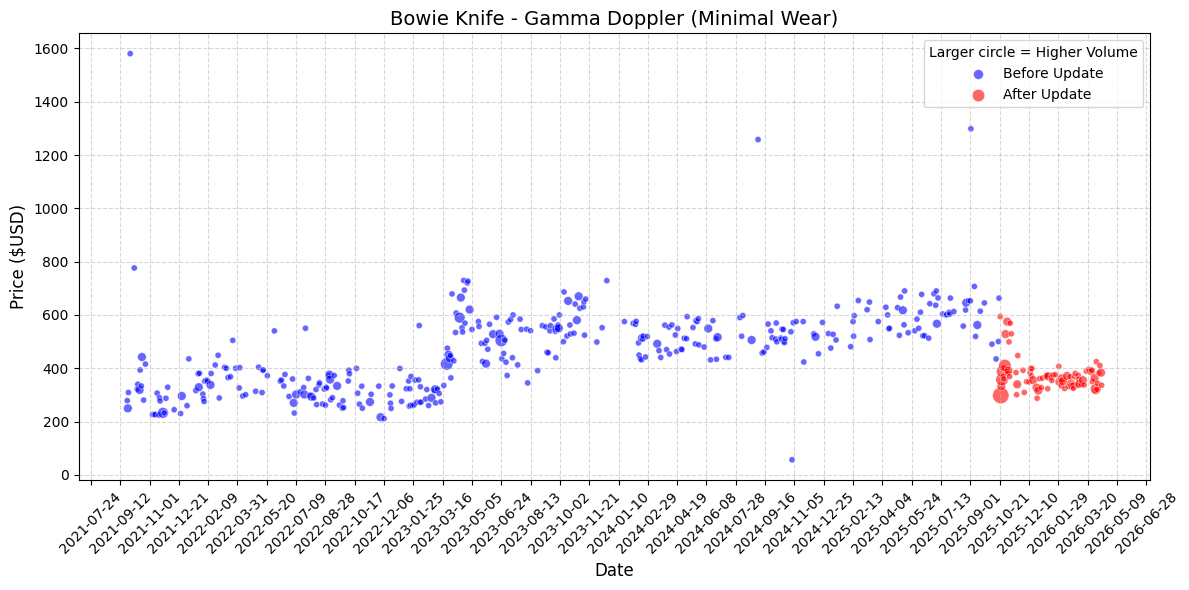

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
csv_path = "data/processed1/Bowie Knife - Gamma Doppler (Minimal Wear).csv"
df = pd.read_csv(csv_path)

df['date'] = pd.to_datetime(df['date'])

b_update = df[df['date'] < '2025-10-22'] # Before Update
a_update = df[df['date'] >= '2025-10-22'] # After Update
plt.figure(figsize=(12, 6))

plt.scatter(b_update['date'], b_update['price'], s=b_update['volume']*20, alpha=0.6, edgecolors="w", linewidth=0.5,c='blue',label='Before Update')
plt.scatter(a_update['date'], a_update['price'], s=a_update['volume']*20, alpha=0.6, edgecolors="w", linewidth=0.5,c='red',label='After Update')
plt.title('Bowie Knife - Gamma Doppler (Minimal Wear)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Colors')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=50))
plt.xticks(rotation=45)
plt.legend(title="Larger circle = Higher Volume")
plt.tight_layout()
plt.show()

### Few observations
- A sharp drop in price after the update
- Volume increased after the update, there could be two reasons that explain it:
    1. "Gold" items became craftable so more items were flooded into the market
    2. People started panic selling because they were afraid that they will lose money.
- These two can be analyzed by comparing just the volumes and just the prices

<Figure size 640x480 with 0 Axes>

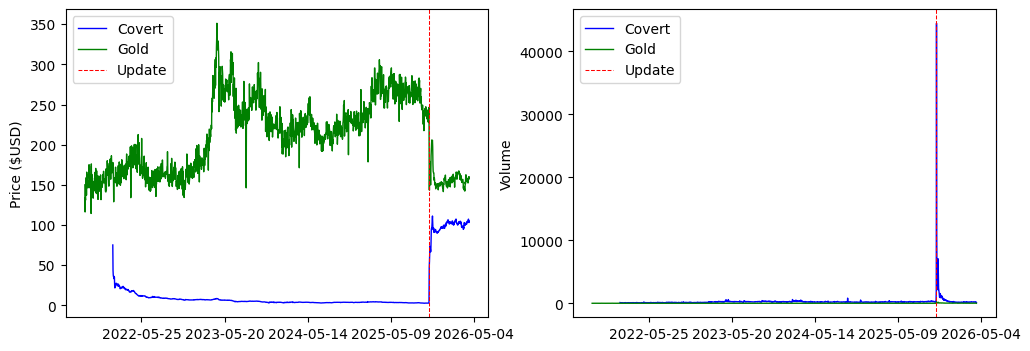

In [6]:
from datetime import datetime
import pandas as pd
covert_path = "data/processed1/MP9 - Starlight Protector (Field-Tested).csv"
gold_path = "data/processed1/Falchion Knife - Lore (Field-Tested).csv"
df_c = pd.read_csv(covert_path)
df_g = pd.read_csv(gold_path)

df_c['date'] = pd.to_datetime(df_c['date'])
df_g['date'] = pd.to_datetime(df_g['date'])
plt.clf()
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(df_c['date'],df_c['price'], linewidth=1,c='blue',label="Covert")
plt.plot(df_g['date'],df_g['price'], linewidth=1,c='green',label="Gold")
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=360))
plt.axvline(x=datetime(2025,10,22), color='r', linestyle='--', label='Update',linewidth=0.75)
plt.ylabel("Price ($USD)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(df_c['date'],df_c['volume'], linewidth=1,c='blue',label="Covert")
plt.plot(df_g['date'],df_g['volume'], linewidth=1,c='green',label="Gold")
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=360))
plt.axvline(x=datetime(2025,10,22), color='r', linestyle='--', label='Update',linewidth=0.75)
plt.ylabel("Volume")
plt.legend()
plt.show()

##### For the prices there is a sudden drop in Gold items and a high increase in Covert items. That was already expected but the interesting thing is with the volume. It increased so much that the volume of the Gold item seems like a flat line compared to it. To see it better we can use log scale for the y axis.

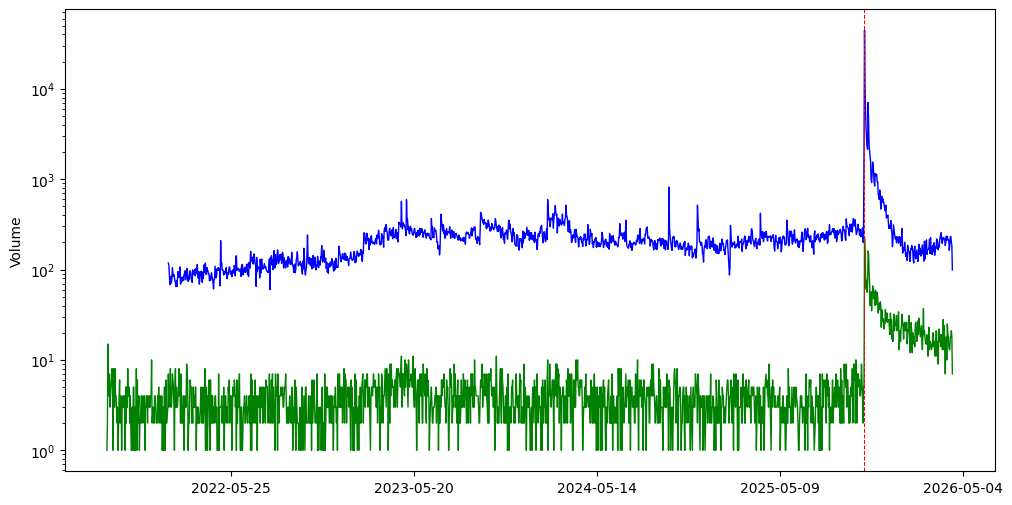

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df_c['date'],df_c['volume'], linewidth=1,c='blue',label="Covert")
plt.plot(df_g['date'],df_g['volume'], linewidth=1,c='green',label="Gold")
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=360))
plt.axvline(x=datetime(2025,10,22), color='r', linestyle='--', label='Update',linewidth=0.75)
plt.yscale('log')
plt.ylabel("Volume")
plt.show()

### Now re-testing with another combination of covert and gold.

<Figure size 640x480 with 0 Axes>

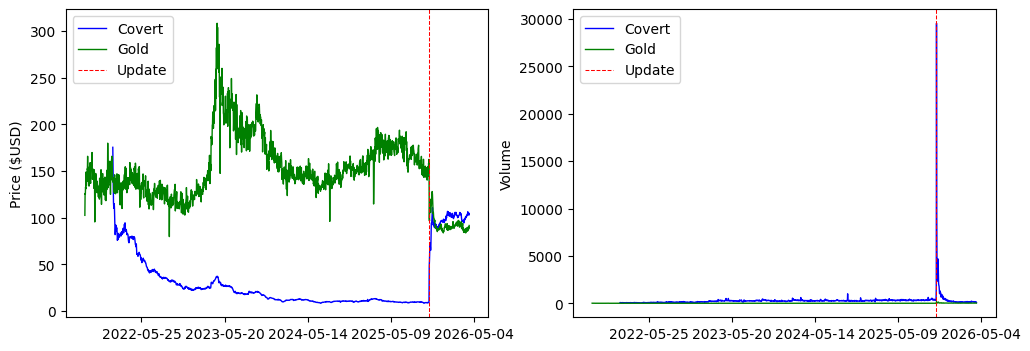

In [8]:
from datetime import datetime
covert_path = "data/processed1/AK-47 - Nightwish (Field-Tested).csv"
gold_path = "data/processed1/Shadow Daggers - Lore (Field-Tested).csv"
df_c = pd.read_csv(covert_path)
df_g = pd.read_csv(gold_path)

df_c['date'] = pd.to_datetime(df_c['date'])
df_g['date'] = pd.to_datetime(df_g['date'])
plt.clf()
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(df_c['date'],df_c['price'], linewidth=1,c='blue',label="Covert")
plt.plot(df_g['date'],df_g['price'], linewidth=1,c='green',label="Gold")
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=360))
plt.axvline(x=datetime(2025,10,22), color='r', linestyle='--', label='Update',linewidth=0.75)
plt.ylabel("Price ($USD)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(df_c['date'],df_c['volume'], linewidth=1,c='blue',label="Covert")
plt.plot(df_g['date'],df_g['volume'], linewidth=1,c='green',label="Gold")
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=360))
plt.axvline(x=datetime(2025,10,22), color='r', linestyle='--', label='Update',linewidth=0.75)
plt.ylabel("Volume")
plt.legend()
plt.show()

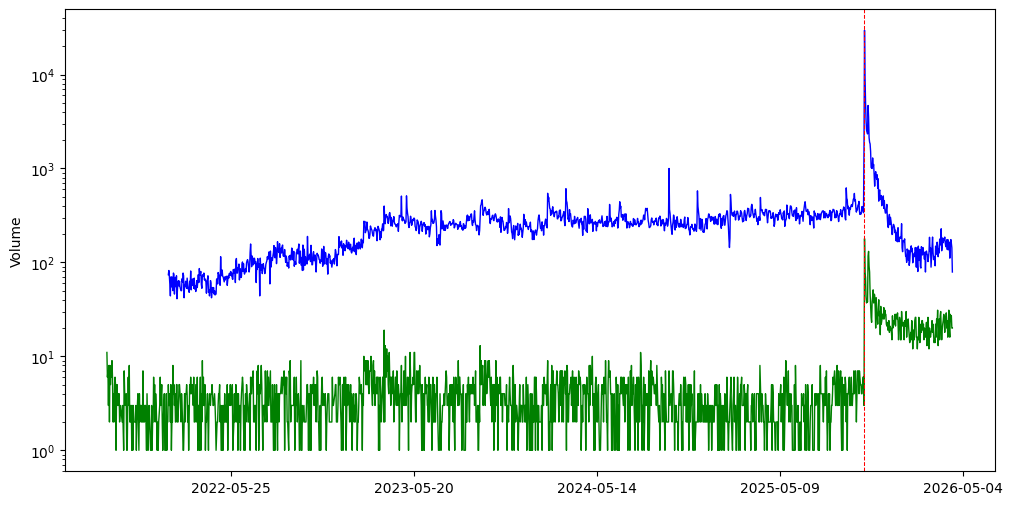

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df_c['date'],df_c['volume'], linewidth=1,c='blue',label="Covert")
plt.plot(df_g['date'],df_g['volume'], linewidth=1,c='green',label="Gold")
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=360))
plt.axvline(x=datetime(2025,10,22), color='r', linestyle='--', label='Update',linewidth=0.75)
plt.yscale('log')
plt.ylabel("Volume")
plt.show()

#### It is now much clearer. At the beginning of this study, I thought the volumes of Covert items would decrease since they would be erased in "trade-up contracts" but it seems like people tried to make quick profit by selling their Covert items in their inventories and thus flooding the market with them.

##### Note: I didn't calculate any mean, median or variance but they will be calculated during the tests in hypothesis testing stage.